In [225]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Baseline Scenario Forecast

In [226]:
# -------------------------------
# 1. INPUT DATA (ALIGN ALL SERIES)
# -------------------------------

retail_pd_forecast = pd.read_csv("./output/retail_pd_baseline_forecast.csv", usecols=['date', 'PD'])
wholesale_pd_forecast = pd.read_csv("./PD forecast/Probability Default - Baseline.csv", usecols=['Quarter', 'Probability of Default'])
wholesale_lgd_forecast = pd.read_csv("./output/wholesale_lgd_historical_forecast_baseline.csv", usecols=['Quarter', 'Wholesale_LGD'])
ppnr_forecast = pd.read_csv("./output/ppnr_historical_forecast_baseline.csv", usecols=['Quarter', 'PPNR'])

retail_pd_forecast = retail_pd_forecast[retail_pd_forecast['date'] >= '2026-01-01'].reset_index(drop=True)
wholesale_pd_forecast = wholesale_pd_forecast[wholesale_pd_forecast['Quarter'] >= '2026-01-01'].reset_index(drop=True)
wholesale_lgd_forecast = wholesale_lgd_forecast[wholesale_lgd_forecast['Quarter'] >= '2026-01-01'].reset_index(drop=True)
ppnr_forecast = ppnr_forecast[ppnr_forecast['Quarter'] >= '2026-01-01'].reset_index(drop=True)

wholesale_pd_forecast[["year", "quarter"]] = wholesale_pd_forecast["Quarter"].str.split("Q", expand=True)
wholesale_pd_forecast["quarter"] = wholesale_pd_forecast["quarter"].str.replace("Q", "").astype(int)
wholesale_lgd_forecast[["year", "quarter"]] = wholesale_lgd_forecast["Quarter"].str.split("Q", expand=True)
wholesale_lgd_forecast["quarter"] = wholesale_lgd_forecast["quarter"].str.replace("Q", "").astype(int)
ppnr_forecast[["year", "quarter"]] = ppnr_forecast["Quarter"].str.split("Q", expand=True)
ppnr_forecast["quarter"] = ppnr_forecast["quarter"].str.replace("Q", "").astype(int)

wholesale_pd_forecast["date"] = pd.PeriodIndex.from_fields(year=wholesale_pd_forecast["year"].astype(int),quarter=wholesale_pd_forecast["quarter"],freq="Q").to_timestamp(how="start")
wholesale_lgd_forecast["date"] = pd.PeriodIndex.from_fields(year=wholesale_lgd_forecast["year"].astype(int),quarter=wholesale_lgd_forecast["quarter"],freq="Q").to_timestamp(how="start")
ppnr_forecast["date"] = pd.PeriodIndex.from_fields(year=ppnr_forecast["year"].astype(int),quarter=ppnr_forecast["quarter"],freq="Q").to_timestamp(how="start")

# Ensure all forecasts are aligned by date
df_baseline = pd.DataFrame({
    "date": retail_pd_forecast["date"],
    "retail_pd": retail_pd_forecast["PD"],
    "wholesale_pd": wholesale_pd_forecast["Probability of Default"],
    "wholesale_lgd": wholesale_lgd_forecast["Wholesale_LGD"],
    "ppnr": ppnr_forecast["PPNR"]
})

df_baseline["date"] = pd.to_datetime(df_baseline["date"])

# Convert PPNR from millions → dollars
df_baseline["ppnr"] = df_baseline["ppnr"] * 1e6

print(df_baseline)
# print(ppnr_forecast.head())

         date  retail_pd  wholesale_pd  wholesale_lgd          ppnr
0  2026-01-01   0.034395      0.023440       0.434817  2.172361e+10
1  2026-04-01   0.039590      0.024051       0.440842  2.193476e+10
2  2026-07-01   0.044346      0.024069       0.451617  2.200935e+10
3  2026-10-01   0.048683      0.024583       0.451753  2.203558e+10
4  2027-01-01   0.052610      0.024569       0.445575  2.204480e+10
5  2027-04-01   0.056221      0.025125       0.436372  2.204803e+10
6  2027-07-01   0.059512      0.025073       0.433707  2.204917e+10
7  2027-10-01   0.062655      0.025701       0.433675  2.228561e+10
8  2028-01-01   0.065318      0.025778       0.434636  2.213225e+10
9  2028-04-01   0.067604      0.025812       0.438995  2.207869e+10
10 2028-07-01   0.069741      0.025835       0.438405  2.205992e+10
11 2028-10-01   0.071748      0.025857       0.437959  2.205334e+10
12 2029-01-01   0.073621      0.025802       0.437385  2.205103e+10


In [227]:
# -------------------------------
# 2. EAD (FROM FED DATA + SCALING)
# -------------------------------

MARKET_SHARE = 0.12 # JPMC has ~12% market share in total assets among top banks

# Fed balances (in millions → convert to $)
retail_balance = 1004316 * 1e6 # $120B
wholesale_balance = 1965463 * 1e6 # $240B

# Scale to single bank
retail_balance *= MARKET_SHARE
wholesale_balance *= MARKET_SHARE

# Scenario (change if needed)
scenario = "baseline" # options: "baseline", "adverse"

def get_ead_multiplier(scenario):
    if scenario == "baseline":
        return 1.0, 1.0
    elif scenario == "adverse":
        return 0.95, 0.90
    else:
        return 0.90, 0.80

retail_mult, wholesale_mult = get_ead_multiplier(scenario)

df_baseline["ead_retail"] = retail_balance * retail_mult
df_baseline["ead_wholesale"] = wholesale_balance * wholesale_mult

print(df_baseline.head())

        date  retail_pd  wholesale_pd  wholesale_lgd          ppnr  \
0 2026-01-01   0.034395      0.023440       0.434817  2.172361e+10   
1 2026-04-01   0.039590      0.024051       0.440842  2.193476e+10   
2 2026-07-01   0.044346      0.024069       0.451617  2.200935e+10   
3 2026-10-01   0.048683      0.024583       0.451753  2.203558e+10   
4 2027-01-01   0.052610      0.024569       0.445575  2.204480e+10   

     ead_retail  ead_wholesale  
0  1.205179e+11   2.358556e+11  
1  1.205179e+11   2.358556e+11  
2  1.205179e+11   2.358556e+11  
3  1.205179e+11   2.358556e+11  
4  1.205179e+11   2.358556e+11  


In [228]:
# -------------------------------
# 3. LOSS CALCULATION
# -------------------------------

RETAIL_LGD = 0.90

df_baseline["retail_loss"] = df_baseline["retail_pd"] * RETAIL_LGD * df_baseline["ead_retail"]
df_baseline["wholesale_loss"] = df_baseline["wholesale_pd"] * df_baseline["wholesale_lgd"] * df_baseline["ead_wholesale"]

df_baseline["total_loss"] = df_baseline["retail_loss"] + df_baseline["wholesale_loss"]

# -------------------------------
# 4. CALIBRATE LOSSES TO REAL DATA
# -------------------------------

target_loss = 2849 * 1e6   # JPM quarterly provision for credit losses from 2025Q2 10Q

scaling_factor = target_loss / df_baseline["total_loss"].iloc[0]

df_baseline["retail_loss"] *= scaling_factor
df_baseline["wholesale_loss"] *= scaling_factor
df_baseline["total_loss"] *= scaling_factor

if scenario == "adverse":
    df_baseline["total_loss"] *= 1.3
# elif scenario == "severely_adverse":
#     df_baseline["total_loss"] *= 1.8

print(df_baseline.head())

        date  retail_pd  wholesale_pd  wholesale_lgd          ppnr  \
0 2026-01-01   0.034395      0.023440       0.434817  2.172361e+10   
1 2026-04-01   0.039590      0.024051       0.440842  2.193476e+10   
2 2026-07-01   0.044346      0.024069       0.451617  2.200935e+10   
3 2026-10-01   0.048683      0.024583       0.451753  2.203558e+10   
4 2027-01-01   0.052610      0.024569       0.445575  2.204480e+10   

     ead_retail  ead_wholesale   retail_loss  wholesale_loss    total_loss  
0  1.205179e+11   2.358556e+11  1.732619e+09    1.116381e+09  2.849000e+09  
1  1.205179e+11   2.358556e+11  1.994301e+09    1.161382e+09  3.155682e+09  
2  1.205179e+11   2.358556e+11  2.233854e+09    1.190667e+09  3.424520e+09  
3  1.205179e+11   2.358556e+11  2.452355e+09    1.216446e+09  3.668801e+09  
4  1.205179e+11   2.358556e+11  2.650141e+09    1.199138e+09  3.849279e+09  


In [229]:
# -------------------------------
# 5. INCOME
# -------------------------------

def stress_ppnr(ppnr, scenario): # Apply stress to PPNR based on scenario
    if scenario == "baseline":
        return ppnr
    elif scenario == "adverse":
        return ppnr * 0.75
    # else:  # severely adverse
    #     return ppnr * 0.55

df_baseline["ppnr"] = df_baseline["ppnr"].apply(lambda x: stress_ppnr(x, "baseline"))

TAX_RATE = 3297 / 18284  # ~18% # Effective tax rate from 2025Q2 10Q (tax expense / pre-tax income)
payout_ratio = 0.3 # Assume 30% of net income is paid out as dividends, rest goes to CET1 capital

df_baseline["pre_tax_income"] = df_baseline["ppnr"] - df_baseline["total_loss"]
df_baseline["tax"] = np.maximum(df_baseline["pre_tax_income"], 0) * TAX_RATE
df_baseline["net_income"] = (df_baseline["pre_tax_income"] - df_baseline["tax"])* (1 - payout_ratio)
print(df_baseline.head())

        date  retail_pd  wholesale_pd  wholesale_lgd          ppnr  \
0 2026-01-01   0.034395      0.023440       0.434817  2.172361e+10   
1 2026-04-01   0.039590      0.024051       0.440842  2.193476e+10   
2 2026-07-01   0.044346      0.024069       0.451617  2.200935e+10   
3 2026-10-01   0.048683      0.024583       0.451753  2.203558e+10   
4 2027-01-01   0.052610      0.024569       0.445575  2.204480e+10   

     ead_retail  ead_wholesale   retail_loss  wholesale_loss    total_loss  \
0  1.205179e+11   2.358556e+11  1.732619e+09    1.116381e+09  2.849000e+09   
1  1.205179e+11   2.358556e+11  1.994301e+09    1.161382e+09  3.155682e+09   
2  1.205179e+11   2.358556e+11  2.233854e+09    1.190667e+09  3.424520e+09   
3  1.205179e+11   2.358556e+11  2.452355e+09    1.216446e+09  3.668801e+09   
4  1.205179e+11   2.358556e+11  2.650141e+09    1.199138e+09  3.849279e+09   

   pre_tax_income           tax    net_income  
0    1.887461e+10  3.403500e+09  1.082978e+10  
1    1.877908e

In [230]:
# -------------------------------
# 6. CET1 INITIALIZATION
# -------------------------------

initial_cet1_capital = 336879 * 1e6 # Common stockholders' equity from 2025Q2 10Q
initial_cet1_ratio = 0.151 # 2025Q2 10Q reports ~15% CET1 ratio from 2025Q2 10Q
initial_rwa = initial_cet1_capital / initial_cet1_ratio

# -------------------------------
# 7. CET1 EVOLUTION
# -------------------------------

cet1_list = []
cet1 = initial_cet1_capital

for ni in df_baseline["net_income"]:
    cet1 = cet1 + ni
    cet1_list.append(cet1)

df_baseline["cet1_capital"] = cet1_list

# -------------------------------
# 8. CET1 RATIO
# -------------------------------

def rwa_growth(scenario):  # Assume RWA grows by 0% in baseline 4% in severely adverse
    if scenario == "baseline":
        return 0.00
    elif scenario == "adverse":
        return 0.02
    else:
        return 0.04

growth = rwa_growth(scenario)

rwa_list = []
rwa = initial_rwa

for _ in df_baseline.index:
    rwa = rwa * (1 + growth)
    rwa_list.append(rwa)

df_baseline["rwa"] = rwa_list

# df_baseline["rwa"] = initial_rwa  # constant RWA

df_baseline["cet1_ratio"] = df_baseline["cet1_capital"] / df_baseline["rwa"]

print(df_baseline.head())

        date  retail_pd  wholesale_pd  wholesale_lgd          ppnr  \
0 2026-01-01   0.034395      0.023440       0.434817  2.172361e+10   
1 2026-04-01   0.039590      0.024051       0.440842  2.193476e+10   
2 2026-07-01   0.044346      0.024069       0.451617  2.200935e+10   
3 2026-10-01   0.048683      0.024583       0.451753  2.203558e+10   
4 2027-01-01   0.052610      0.024569       0.445575  2.204480e+10   

     ead_retail  ead_wholesale   retail_loss  wholesale_loss    total_loss  \
0  1.205179e+11   2.358556e+11  1.732619e+09    1.116381e+09  2.849000e+09   
1  1.205179e+11   2.358556e+11  1.994301e+09    1.161382e+09  3.155682e+09   
2  1.205179e+11   2.358556e+11  2.233854e+09    1.190667e+09  3.424520e+09   
3  1.205179e+11   2.358556e+11  2.452355e+09    1.216446e+09  3.668801e+09   
4  1.205179e+11   2.358556e+11  2.650141e+09    1.199138e+09  3.849279e+09   

   pre_tax_income           tax    net_income  cet1_capital           rwa  \
0    1.887461e+10  3.403500e+09  

         date    total_loss    net_income  cet1_ratio
0  2026-01-01  2.849000e+09  1.082978e+10    0.155854
1  2026-04-01  3.155682e+09  1.077496e+10    0.160684
2  2026-07-01  3.424520e+09  1.066351e+10    0.165464
3  2026-10-01  3.668801e+09  1.053840e+10    0.170187
4  2027-01-01  3.849279e+09  1.044013e+10    0.174867
5  2027-04-01  4.032991e+09  1.033658e+10    0.179500
6  2027-07-01  4.188953e+09  1.024774e+10    0.184093
7  2027-10-01  4.377043e+09  1.027548e+10    0.188699
8  2028-01-01  4.517555e+09  1.010687e+10    0.193229
9  2028-04-01  4.646653e+09  1.000206e+10    0.197713
10 2028-07-01  4.753724e+09  9.929861e+09    0.202164
11 2028-10-01  4.854605e+09  9.868201e+09    0.206587
12 2029-01-01  4.944724e+09  9.815168e+09    0.210986

Min CET1 Ratio: 0.15585425436003605


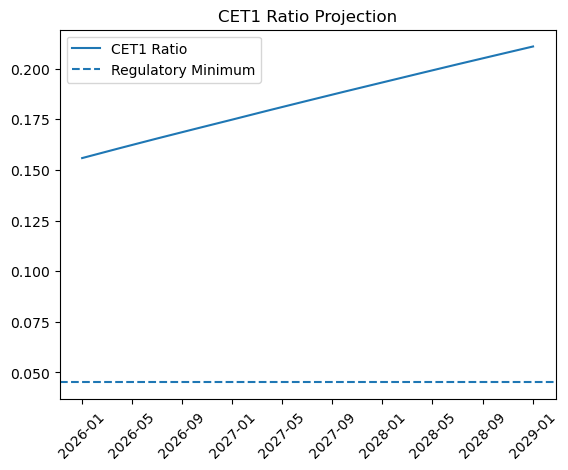

In [231]:
# -------------------------------
# 9. RESULTS
# -------------------------------

print(df_baseline[["date","total_loss","net_income","cet1_ratio"]])

print("\nMin CET1 Ratio:", df_baseline["cet1_ratio"].min())

# -------------------------------
# 10. PLOT
# -------------------------------

plt.figure()
plt.plot(df_baseline["date"], df_baseline["cet1_ratio"], label="CET1 Ratio")
plt.axhline(0.045, linestyle="--", label="Regulatory Minimum")
plt.title("CET1 Ratio Projection")
plt.legend()
plt.xticks(rotation=45)
plt.show()

## Severely Adverse Scenario Forecast

In [232]:
# -------------------------------
# 1. INPUT DATA (ALIGN ALL SERIES)
# -------------------------------

retail_pd_forecast = pd.read_csv("./output/retail_pd_adverse_forecast.csv", usecols=['date', 'PD'])
wholesale_pd_forecast = pd.read_csv("./PD forecast/Probability Default - Severely Adverse.csv", usecols=['Quarter', 'Probability of Default'])
wholesale_lgd_forecast = pd.read_csv("./output/wholesale_lgd_historical_forecast_severely_adverse.csv", usecols=['Quarter', 'Wholesale_LGD'])
ppnr_forecast = pd.read_csv("./output/ppnr_historical_forecast_severely_adverse.csv", usecols=['Quarter', 'PPNR'])

retail_pd_forecast = retail_pd_forecast[retail_pd_forecast['date'] >= '2026-01-01'].reset_index(drop=True)
wholesale_pd_forecast = wholesale_pd_forecast[wholesale_pd_forecast['Quarter'] >= '2026-01-01'].reset_index(drop=True)
wholesale_lgd_forecast = wholesale_lgd_forecast[wholesale_lgd_forecast['Quarter'] >= '2026-01-01'].reset_index(drop=True)
ppnr_forecast = ppnr_forecast[ppnr_forecast['Quarter'] >= '2026-01-01'].reset_index(drop=True)

wholesale_pd_forecast[["year", "quarter"]] = wholesale_pd_forecast["Quarter"].str.split("Q", expand=True)
wholesale_pd_forecast["quarter"] = wholesale_pd_forecast["quarter"].str.replace("Q", "").astype(int)
wholesale_lgd_forecast[["year", "quarter"]] = wholesale_lgd_forecast["Quarter"].str.split("Q", expand=True)
wholesale_lgd_forecast["quarter"] = wholesale_lgd_forecast["quarter"].str.replace("Q", "").astype(int)
ppnr_forecast[["year", "quarter"]] = ppnr_forecast["Quarter"].str.split("Q", expand=True)
ppnr_forecast["quarter"] = ppnr_forecast["quarter"].str.replace("Q", "").astype(int)

wholesale_pd_forecast["date"] = pd.PeriodIndex.from_fields(year=wholesale_pd_forecast["year"].astype(int),quarter=wholesale_pd_forecast["quarter"],freq="Q").to_timestamp(how="start")
wholesale_lgd_forecast["date"] = pd.PeriodIndex.from_fields(year=wholesale_lgd_forecast["year"].astype(int),quarter=wholesale_lgd_forecast["quarter"],freq="Q").to_timestamp(how="start")
ppnr_forecast["date"] = pd.PeriodIndex.from_fields(year=ppnr_forecast["year"].astype(int),quarter=ppnr_forecast["quarter"],freq="Q").to_timestamp(how="start")

# Ensure all forecasts are aligned by date
df_adverse = pd.DataFrame({
    "date": retail_pd_forecast["date"],
    "retail_pd": retail_pd_forecast["PD"],
    "wholesale_pd": wholesale_pd_forecast["Probability of Default"],
    "wholesale_lgd": wholesale_lgd_forecast["Wholesale_LGD"],
    "ppnr": ppnr_forecast["PPNR"]
})

df_adverse["date"] = pd.to_datetime(df_adverse["date"])

# Convert PPNR from millions → dollars
df_adverse["ppnr"] = df_adverse["ppnr"] * 1e6

print(df_adverse)
# print(ppnr_forecast.head())

         date  retail_pd  wholesale_pd  wholesale_lgd          ppnr
0  2026-01-01   0.037056      0.042347       0.543112  1.952933e+10
1  2026-04-01   0.042878      0.048775       0.705712  1.820378e+10
2  2026-07-01   0.048794      0.049027       0.758817  1.720187e+10
3  2026-10-01   0.054498      0.049076       0.794203  1.668489e+10
4  2027-01-01   0.059292      0.046661       0.819238  1.650717e+10
5  2027-04-01   0.063310      0.043809       0.802655  1.644525e+10
6  2027-07-01   0.066340      0.040575       0.769795  1.659940e+10
7  2027-10-01   0.068672      0.036922       0.744041  1.665383e+10
8  2028-01-01   0.070190      0.033469       0.721677  1.667298e+10
9  2028-04-01   0.070765      0.030427       0.673796  1.685826e+10
10 2028-07-01   0.070545      0.027898       0.610796  1.692377e+10
11 2028-10-01   0.069730      0.024867       0.539160  1.712824e+10
12 2029-01-01   0.068560      0.022375       0.461092  1.738471e+10


In [233]:
# -------------------------------
# 2. EAD (FROM FED DATA + SCALING)
# -------------------------------

MARKET_SHARE = 0.12 # JPMC has ~12% market share in total assets among top banks

# Fed balances (in millions → convert to $)
retail_balance = 1004316 * 1e6 # $120B
wholesale_balance = 1965463 * 1e6 # $240B

# Scale to single bank
retail_balance *= MARKET_SHARE
wholesale_balance *= MARKET_SHARE

# Scenario (change if needed)
scenario = "adverse" # options: "baseline", "adverse"

def get_ead_multiplier(scenario):
    if scenario == "baseline":
        return 1.0, 1.0
    elif scenario == "adverse":
        # return 0.95, 0.90
        return 0.90, 0.80
    else:
        return 0.90, 0.80

retail_mult, wholesale_mult = get_ead_multiplier(scenario)

df_adverse["ead_retail"] = retail_balance * retail_mult
df_adverse["ead_wholesale"] = wholesale_balance * wholesale_mult

print(df_adverse.head())

        date  retail_pd  wholesale_pd  wholesale_lgd          ppnr  \
0 2026-01-01   0.037056      0.042347       0.543112  1.952933e+10   
1 2026-04-01   0.042878      0.048775       0.705712  1.820378e+10   
2 2026-07-01   0.048794      0.049027       0.758817  1.720187e+10   
3 2026-10-01   0.054498      0.049076       0.794203  1.668489e+10   
4 2027-01-01   0.059292      0.046661       0.819238  1.650717e+10   

     ead_retail  ead_wholesale  
0  1.084661e+11   1.886844e+11  
1  1.084661e+11   1.886844e+11  
2  1.084661e+11   1.886844e+11  
3  1.084661e+11   1.886844e+11  
4  1.084661e+11   1.886844e+11  


In [234]:
# -------------------------------
# 3. LOSS CALCULATION
# -------------------------------

RETAIL_LGD = 0.90

df_adverse["retail_loss"] = df_adverse["retail_pd"] * RETAIL_LGD * df_adverse["ead_retail"]
df_adverse["wholesale_loss"] = df_adverse["wholesale_pd"] * df_adverse["wholesale_lgd"] * df_adverse["ead_wholesale"]

df_adverse["total_loss"] = df_adverse["retail_loss"] + df_adverse["wholesale_loss"]

# -------------------------------
# 4. CALIBRATE LOSSES TO REAL DATA
# -------------------------------

target_loss = 2849 * 1e6   # JPM quarterly provision for credit losses from 2025Q2 10Q

scaling_factor = target_loss / df_adverse["total_loss"].iloc[0]

df_adverse["retail_loss"] *= scaling_factor
df_adverse["wholesale_loss"] *= scaling_factor
df_adverse["total_loss"] *= scaling_factor

# if scenario == "adverse":
#     # df_adverse["total_loss"] *= 1.3
#     df_adverse["total_loss"] *= 1.8
# elif scenario == "severely_adverse":
#     df_adverse["total_loss"] *= 1.8

df_adverse.loc[0:3, "total_loss"] *= 2.5   # first 4 quarters shock
df_adverse.loc[4:6, "total_loss"] *= 1.8   # mid stress

print(df_adverse.head())

        date  retail_pd  wholesale_pd  wholesale_lgd          ppnr  \
0 2026-01-01   0.037056      0.042347       0.543112  1.952933e+10   
1 2026-04-01   0.042878      0.048775       0.705712  1.820378e+10   
2 2026-07-01   0.048794      0.049027       0.758817  1.720187e+10   
3 2026-10-01   0.054498      0.049076       0.794203  1.668489e+10   
4 2027-01-01   0.059292      0.046661       0.819238  1.650717e+10   

     ead_retail  ead_wholesale   retail_loss  wholesale_loss    total_loss  
0  1.084661e+11   1.886844e+11  1.295201e+09    1.553799e+09  7.122500e+09  
1  1.084661e+11   1.886844e+11  1.498693e+09    2.325464e+09  9.560393e+09  
2  1.084661e+11   1.886844e+11  1.705490e+09    2.513336e+09  1.054707e+10  
3  1.084661e+11   1.886844e+11  1.904850e+09    2.633206e+09  1.134514e+10  
4  1.084661e+11   1.886844e+11  2.072424e+09    2.582521e+09  8.378900e+09  


In [235]:
# -------------------------------
# 5. INCOME
# -------------------------------

def stress_ppnr(ppnr, scenario): # Apply stress to PPNR based on scenario
    if scenario == "baseline":
        return ppnr
    elif scenario == "adverse":
        # return ppnr * 0.75
        return ppnr * 0.55
    # else:  # severely adverse
    #     return ppnr * 0.55

def stress_ppnr(ppnr, scenario, t):
    if scenario == "adverse":
        if t < 4:
            return ppnr * 0.45
        elif t < 8:
            return ppnr * 0.60
        else:
            return ppnr * 0.75
    return ppnr

df_adverse["ppnr"] = [stress_ppnr(x, "adverse", i) for i, x in enumerate(df_adverse["ppnr"])]

# df_adverse["ppnr"] = df_adverse["ppnr"].apply(lambda x: stress_ppnr(x, "adverse"))

TAX_RATE = 3297 / 18284  # ~18% # Effective tax rate from 2025Q2 10Q (tax expense / pre-tax income)
payout_ratio = 0.3 # Assume 30% of net income is paid out as dividends, rest goes to CET1 capital

df_adverse["pre_tax_income"] = df_adverse["ppnr"] - df_adverse["total_loss"]
df_adverse["tax"] = np.maximum(df_adverse["pre_tax_income"], 0) * TAX_RATE
df_adverse["net_income"] = (df_adverse["pre_tax_income"] - df_adverse["tax"])* (1 - payout_ratio)
print(df_adverse.head())

        date  retail_pd  wholesale_pd  wholesale_lgd          ppnr  \
0 2026-01-01   0.037056      0.042347       0.543112  8.788197e+09   
1 2026-04-01   0.042878      0.048775       0.705712  8.191701e+09   
2 2026-07-01   0.048794      0.049027       0.758817  7.740843e+09   
3 2026-10-01   0.054498      0.049076       0.794203  7.508200e+09   
4 2027-01-01   0.059292      0.046661       0.819238  9.904303e+09   

     ead_retail  ead_wholesale   retail_loss  wholesale_loss    total_loss  \
0  1.084661e+11   1.886844e+11  1.295201e+09    1.553799e+09  7.122500e+09   
1  1.084661e+11   1.886844e+11  1.498693e+09    2.325464e+09  9.560393e+09   
2  1.084661e+11   1.886844e+11  1.705490e+09    2.513336e+09  1.054707e+10   
3  1.084661e+11   1.886844e+11  1.904850e+09    2.633206e+09  1.134514e+10   
4  1.084661e+11   1.886844e+11  2.072424e+09    2.582521e+09  8.378900e+09   

   pre_tax_income           tax    net_income  
0    1.665697e+09  3.003611e+08  9.557348e+08  
1   -1.368692e

In [236]:
# -------------------------------
# 6. CET1 INITIALIZATION
# -------------------------------

initial_cet1_capital = 336879 * 1e6 # Common stockholders' equity from 2025Q2 10Q
initial_cet1_ratio = 0.151 # 2025Q2 10Q reports ~15% CET1 ratio from 2025Q2 10Q
initial_rwa = initial_cet1_capital / initial_cet1_ratio # ~2.23 trillion

# -------------------------------
# 7. CET1 EVOLUTION
# -------------------------------

cet1_list = []
cet1 = initial_cet1_capital

for ni in df_adverse["net_income"]:
    cet1 = cet1 + ni
    cet1_list.append(cet1)

df_adverse["cet1_capital"] = cet1_list
# -------------------------------
# 8. CET1 RATIO
# -------------------------------

def rwa_growth(scenario):  # Assume RWA grows by 0% in baseline 4% in severely adverse
    if scenario == "baseline":
        return 0.00
    elif scenario == "adverse":
        # return 0.02
        return 0.015
    else:
        return 0.04

growth = rwa_growth(scenario)

rwa_list = []
rwa = initial_rwa

for _ in df_adverse.index:
    rwa = rwa * (1 + growth)
    rwa_list.append(rwa)

df_adverse["rwa"] = rwa_list
# df_adverse["rwa"] = initial_rwa  # constant RWA

df_adverse["cet1_ratio"] = df_adverse["cet1_capital"] / df_adverse["rwa"]

print(df_adverse.head())

        date  retail_pd  wholesale_pd  wholesale_lgd          ppnr  \
0 2026-01-01   0.037056      0.042347       0.543112  8.788197e+09   
1 2026-04-01   0.042878      0.048775       0.705712  8.191701e+09   
2 2026-07-01   0.048794      0.049027       0.758817  7.740843e+09   
3 2026-10-01   0.054498      0.049076       0.794203  7.508200e+09   
4 2027-01-01   0.059292      0.046661       0.819238  9.904303e+09   

     ead_retail  ead_wholesale   retail_loss  wholesale_loss    total_loss  \
0  1.084661e+11   1.886844e+11  1.295201e+09    1.553799e+09  7.122500e+09   
1  1.084661e+11   1.886844e+11  1.498693e+09    2.325464e+09  9.560393e+09   
2  1.084661e+11   1.886844e+11  1.705490e+09    2.513336e+09  1.054707e+10   
3  1.084661e+11   1.886844e+11  1.904850e+09    2.633206e+09  1.134514e+10   
4  1.084661e+11   1.886844e+11  2.072424e+09    2.582521e+09  8.378900e+09   

   pre_tax_income           tax    net_income  cet1_capital           rwa  \
0    1.665697e+09  3.003611e+08  

         date    total_loss    net_income  cet1_ratio
0  2026-01-01  7.122500e+09  9.557348e+08    0.149191
1  2026-04-01  9.560393e+09 -9.580845e+08    0.146569
2  2026-07-01  1.054707e+10 -1.964356e+09    0.143561
3  2026-10-01  1.134514e+10 -2.685859e+09    0.140305
4  2027-01-01  8.378900e+09  8.752377e+08    0.138596
5  2027-04-01  8.259169e+09  9.226203e+08    0.136926
6  2027-07-01  7.972026e+09  1.140442e+09    0.135363
7  2027-10-01  4.256187e+09  3.291237e+09    0.134672
8  2028-01-01  4.085113e+09  4.830967e+09    0.134575
9  2028-04-01  3.858486e+09  5.040733e+09    0.134534
10 2028-07-01  3.616945e+09  5.207513e+09    0.134527
11 2028-10-01  3.343051e+09  5.452655e+09    0.134583
12 2029-01-01  3.093350e+09  5.706295e+09    0.134702

Min CET1 Ratio: 0.13452691603951336


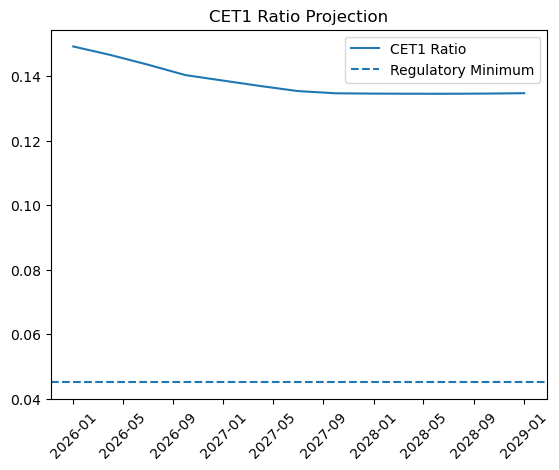

In [237]:
# -------------------------------
# 9. RESULTS
# -------------------------------

print(df_adverse[["date","total_loss","net_income","cet1_ratio"]])

print("\nMin CET1 Ratio:", df_adverse["cet1_ratio"].min())

# -------------------------------
# 10. PLOT
# -------------------------------

plt.figure()
plt.plot(df_adverse["date"], df_adverse["cet1_ratio"], label="CET1 Ratio")
plt.axhline(0.045, linestyle="--", label="Regulatory Minimum")
plt.title("CET1 Ratio Projection")
plt.legend()
plt.xticks(rotation=45)
plt.show()